# Churn Prediction Experiments & Proposal Alignment
This notebook tests Logistic Regression, Random Forest, and Support Vector Machines (SVM) for churn prediction, as well as performing GPU availability checks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE


## 1. Data Loading and Preparation

In [2]:
data = pd.read_csv(r"/mnt/d/Rafay/fyp/backend/data/raw/ecommerce_customer_data_custom_ratios.csv")
data = data.dropna()

for col in data.select_dtypes(include=["object"]).columns:
    if col != "CustomerID":
        data[col] = LabelEncoder().fit_transform(data[col])

X = data.drop(columns=["Churn", "CustomerID"], errors="ignore")
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print("Data balanced via SMOTE.")


Data balanced via SMOTE.


## 2. Model Implementations (Methodology: LogReg, SVM, Random Forest)

In [4]:
# 1. Logistic Regression
print("Training Logistic Regression...")
log_model = LogisticRegression(max_iter=500, random_state=42)
log_model.fit(X_train_balanced, y_train_balanced)
acc_log = accuracy_score(y_test, log_model.predict(X_test_scaled))

# 2. Support Vector Machines (SVM - Optimized for large datasets)
from sklearn.svm import LinearSVC
print("Training SVM (LinearSVC)...")
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_balanced, y_train_balanced)
acc_svm = accuracy_score(y_test, svm_model.predict(X_test_scaled))

# 3. Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
acc_rf = accuracy_score(y_test, rf_model.predict(X_test_scaled))

print("\nAccuracy Scores:")
print(f"Logistic Regression: {acc_log:.4f}")
print(f"SVM: {acc_svm:.4f}")
print(f"Random Forest: {acc_rf:.4f}")


Training Logistic Regression...
Training SVM (LinearSVC)...
Training Random Forest...

Accuracy Scores:
Logistic Regression: 0.5043
SVM: 0.5044
Random Forest: 0.7917


## 3. Visualization and Save

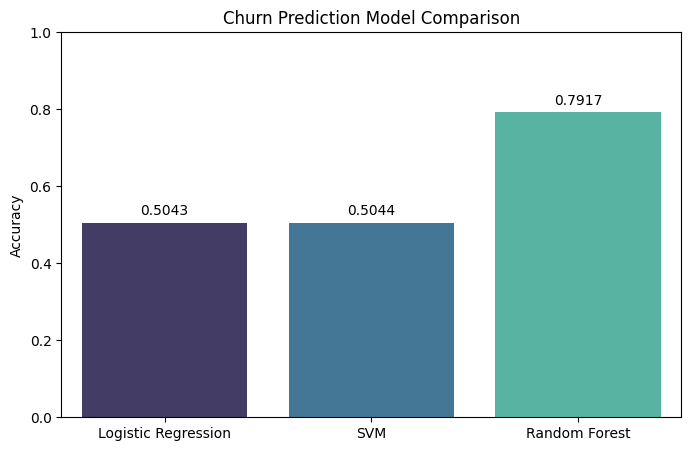

✅ Predictions successfully saved to: /mnt/d/Rafay/fyp/data/processed/churn_predictions_rf.csv


In [ ]:
model_names = ["Logistic Regression", "SVM", "Random Forest"]
accuracies = [acc_log, acc_svm, acc_rf]

plt.figure(figsize=(8,5))
# Deprecation Fix: Passed 'hue' and 'legend=False'
sns.barplot(x=model_names, y=accuracies, hue=model_names, palette="mako", legend=False)
plt.title("Churn Prediction Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

# Accuracies ki values bars ke upper show karne ke liye
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')

plt.show()

# Save final predictions
output_dir = r"/mnt/d/Rafay/fyp/data/processed"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "churn_predictions_rf.csv")

# Using the primary Random Forest model
data["Predicted_Churn"] = rf_model.predict(scaler.transform(X))
data.to_csv(output_path, index=False)
print("✅ Predictions successfully saved to:", output_path)
